# Content LLM

## 1. Inventario de modelos Ollama instalados

| Modelo | Uso | Disco | Parámetros | Dim. embedding | Cuantización | VRAM medida |
|---|---|---|---|---|---|---|
| `qwen3-embedding:latest` | Embeddings (el que usa el notebook) | 4.7 GB | 7.6B | 4096 | Q4_K_M | 10 GB |
| `qwen3-embedding:0.6b` | Embeddings, alternativa liviana | 639 MB | ~596M | 1024 | Q8_0 | 5.8 GB |
| `llama3.2:3b` | Chat/generación (`CHAT_MODEL`) | 2.0 GB | 3.2B | — | Q4_K_M | 6.0 GB (ctx 32768) → 2.3 GB (ctx 2048) |


## 2. Optimización de eficiencia de inferencia
- **Offloading**: mover capas a VRAM (GPU) vs RAM (CPU); "100% GPU" = todo el modelo en VRAM.
- **`num_ctx`**: tamaño de la ventana de contexto reservada por llamada (no el máximo del modelo).
- **`num_predict`**: tope máximo de tokens de salida.

```python
options={
    "num_ctx": 2048,      # antes 32768 (default)
    "num_predict": 200,   # tope de tokens de salida
    "temperature": 0.2,   # respuestas más directas
    "keep_alive": "30m",  # evita recargar el modelo entre celdas
}
```

**Resultado medido:**

| | Antes | Después |
|---|---|---|
| VRAM reservada | 6.0 GB | **2.3 GB** |
| Tokens de salida | sin límite | 33 (tope 200) |
| Tiempo de respuesta | — | 2.49 s |

Docs oficiales: `docs/api.md`, `docs/modelfile.md`, `docs/gpu.md`, `docs/faq.md` en `github.com/ollama/ollama`.



# Arquitecture RAG LOCAL

Medium article 1: https://medium.com/data-science-collective/rag-architectures-a-complete-guide-for-2025-daf98a2ede8c
Medium article 2: https://levelup.gitconnected.com/llm-vs-rag-vs-mcp-i-finally-know-when-to-use-each-one-77403510ba1d

It's a lot of Arquitecture of RAG

In [19]:
import ollama
import chromadb

EMBED_MODEL = "qwen3-embedding"
CHAT_MODEL = "llama3.2:3b"

db   = chromadb.Client()
coll = db.get_or_create_collection("pipeline_docs")

def embed(texts):
    return [ollama.embed(model=EMBED_MODEL, input=t).embeddings[0] for t in texts]

# --- Step 1: Index your corpus (run once) ---
docs = [
    "Delta Lake supports ACID transactions via transaction logs.",
    "Spark broadcast joins send small tables to every executor.",
    "Kafka retention is configured with retention.ms per topic.",
]
coll.add(
    documents=docs,
    embeddings=embed(docs),
    ids=[f"doc-{i}" for i in range(len(docs))]
)

# --- Step 2: Retrieve + generate at query time ---
query   = "How does Spark handle joins with small tables?"
results = coll.query(
    query_embeddings=embed([query]),
    n_results=2
)
context = "\n".join(results["documents"][0])

response = ollama.chat(
    model=CHAT_MODEL,
    messages=[
        {"role": "system", "content": f"Answer using only this context in at most 2 sentences:\n{context}"},
        {"role": "user", "content": query},
    ],
    options={
        "num_ctx": 2048,      # smaller context window = less VRAM, faster prefill (default was 32768)
        "num_predict": 200,   # hard cap on output tokens
        "temperature": 0.2,   # less randomness, more direct answers
        "keep_alive": "30m",  # keep the model loaded between notebook cells
    },
)
print(response.message.content)

Spark handles joins with small tables by joining the data into a broadcast join, where the smaller table is stored in memory on each executor and can be joined with the larger table using a hash join or sort-merge join. This allows for efficient joining of small tables without having to load them all into memory at once.


# Embedding clustering demo: dog & cat breeds

Embeds short breed descriptions with `qwen3-embedding`, reduces to 2D with PCA,
clusters with KMeans, and plots how the model groups them — colored by the
cluster the AI found, shaped by the true species (dog vs cat) so you can see
whether the embedding space actually separates them on its own.

Embedding 31 breed descriptions with qwen3-embedding ...
Embedding matrix shape: (31, 4096)
Adjusted Rand Index vs. true dog/cat split: 1.000 (1.0 = perfect match)


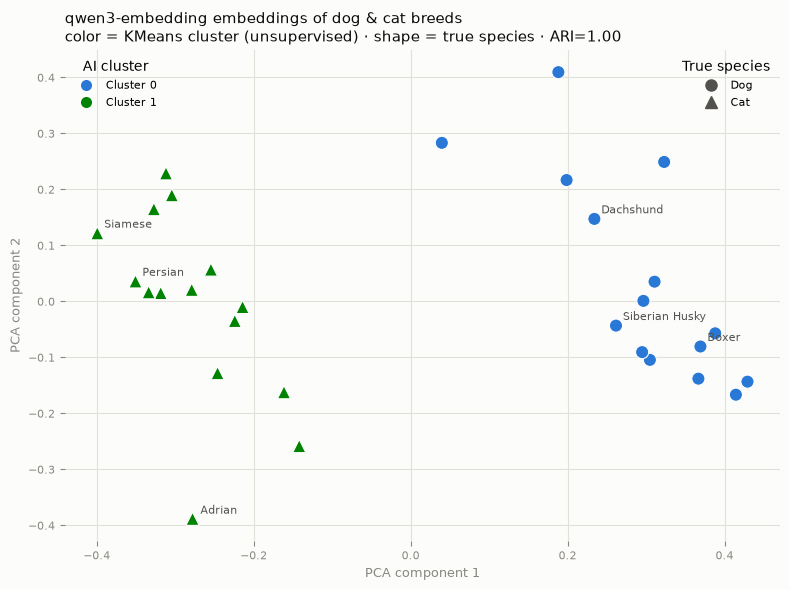

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

breeds = {
    # dogs
    "Labrador Retriever": ("dog", "Friendly, outgoing Labrador Retriever, a medium-large gun dog bred to retrieve waterfowl for hunters."),
    "German Shepherd": ("dog", "Confident, courageous German Shepherd, a large working dog originally bred for herding and guarding sheep."),
    "Golden Retriever": ("dog", "Gentle, intelligent Golden Retriever, a sturdy sporting dog with a dense golden coat, bred to retrieve shot game."),
    "Bulldog": ("dog", "Docile, sturdy Bulldog with a wrinkled face and stocky build, originally bred for bull-baiting in England."),
    "Poodle": ("dog", "Highly intelligent, active Poodle known for its curly hypoallergenic coat, originally a water retriever."),
    "Beagle": ("dog", "Curious, merry Beagle, a small scent hound bred to track hare and rabbit by smell."),
    "Rottweiler": ("dog", "Powerful, loyal Rottweiler, a large muscular breed originally used to drive cattle and pull carts."),
    "Dachshund": ("dog", "Bold, low-slung Dachshund with a long body and short legs, bred to hunt badgers underground."),
    "Siberian Husky": ("dog", "Energetic, athletic Siberian Husky, a medium sled dog bred for endurance in cold Arctic climates."),
    "Chihuahua": ("dog", "Tiny, alert Chihuahua, the smallest dog breed, originating in Mexico and known for its big personality."),
    "Border Collie": ("dog", "Extremely intelligent, agile Border Collie, a herding dog bred to control sheep on the Scottish borders."),
    "Boxer": ("dog", "Playful, muscular Boxer with a square jaw, bred in Germany as a guard and working dog."),
    "Great Dane": ("dog", "Gentle giant Great Dane, one of the tallest dog breeds, originally bred to hunt wild boar."),
    "Shih Tzu": ("dog", "Affectionate, long-haired Shih Tzu, a small companion dog bred in China for royalty."),
    "Australian Shepherd": ("dog", "Versatile, high-energy Australian Shepherd, a herding dog bred on American ranches despite the name."),
    # cats
    "Persian": ("cat", "Calm, long-haired Persian cat with a flat face, prized for its luxurious coat and quiet temperament."),
    "Siamese": ("cat", "Vocal, social Siamese cat with striking blue eyes and a short coat, one of the oldest recognized cat breeds."),
    "Maine Coon": ("cat", "Large, friendly Maine Coon, a rugged long-haired breed developed in the cold climate of New England."),
    "Bengal": ("cat", "Athletic, spotted Bengal cat bred from crossing domestic cats with the wild Asian leopard cat."),
    "British Shorthair": ("cat", "Sturdy, round-faced British Shorthair with a dense plush coat, an easygoing companion breed."),
    "Sphynx": ("cat", "Hairless, energetic Sphynx cat with wrinkled skin, needing regular baths to remove skin oils."),
    "Ragdoll": ("cat", "Docile, affectionate Ragdoll cat that goes limp when picked up, bred for a gentle companion temperament."),
    "Abyssinian": ("cat", "Active, agile Abyssinian cat with a ticked coat, one of the oldest known domestic cat breeds."),
    "Scottish Fold": ("cat", "Sweet-natured Scottish Fold cat known for its folded ears caused by a genetic cartilage mutation."),
    "Russian Blue": ("cat", "Reserved, elegant Russian Blue cat with a dense silvery-blue coat and bright green eyes."),
    "Norwegian Forest Cat": ("cat", "Large, hardy Norwegian Forest cat with a thick water-resistant coat suited to cold Scandinavian winters."),
    "Devon Rex": ("cat", "Playful, mischievous Devon Rex cat with large ears and a soft curly coat, sometimes called a 'pixie cat'."),
    "Burmese": ("cat", "Affectionate, muscular Burmese cat with a glossy short coat, descended from a single cat in Burma."),
    "Turkish Angora": ("cat", "Graceful, silky-coated Turkish Angora, an ancient natural breed from central Turkey."),
    "American Shorthair": ("cat", "Adaptable, easygoing American Shorthair, descended from working cats brought to colonial America."),
    "Adrian": ("andorra", "Adaptable, easygoing American Shorthair, descended from working cats brought to colonial America.")
}

names = list(breeds.keys())
species = [breeds[n][0] for n in names]
texts = [breeds[n][1] for n in names]

print(f"Embedding {len(texts)} breed descriptions with {EMBED_MODEL} ...")
X = np.array(embed(texts))
print("Embedding matrix shape:", X.shape)

# Reduce to 2D for plotting
coords = PCA(n_components=2, random_state=0).fit_transform(X)

# Let the AI's own embedding space group the data (unsupervised)
kmeans = KMeans(n_clusters=2, n_init=10, random_state=0)
cluster_labels = kmeans.fit_predict(X)

true_labels = [0 if s == "dog" else 1 for s in species]
ari = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index vs. true dog/cat split: {ari:.3f} (1.0 = perfect match)")

# --- Plot ---
CLUSTER_COLORS = ["#2a78d6", "#008300"]   # validated categorical slots 1 & 2 (blue, green)
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"

fig, ax = plt.subplots(figsize=(8, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

marker_by_species = {"dog": "o", "cat": "^"}
for sp, marker in marker_by_species.items():
    mask = [s == sp for s in species]
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[CLUSTER_COLORS[c] for c in np.array(cluster_labels)[mask]],
        marker=marker, s=90, edgecolors="white", linewidths=0.8,
        label=None, zorder=3,
    )

# label a few representative points per cluster (selective, not every point)
rng = np.random.default_rng(0)
for c in (0, 1):
    idx = np.where(np.array(cluster_labels) == c)[0]
    for i in rng.choice(idx, size=min(3, len(idx)), replace=False):
        ax.annotate(
            names[i], (coords[i, 0], coords[i, 1]),
            fontsize=8, color=INK_SECONDARY,
            xytext=(5, 4), textcoords="offset points",
        )

ax.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors=INK_MUTED, labelsize=8)
ax.set_xlabel("PCA component 1", color=INK_MUTED, fontsize=9)
ax.set_ylabel("PCA component 2", color=INK_MUTED, fontsize=9)
ax.set_title(
    f"{EMBED_MODEL} embeddings of dog & cat breeds\n"
    f"color = KMeans cluster (unsupervised) · shape = true species · ARI={ari:.2f}",
    color=INK_PRIMARY, fontsize=11, loc="left",
)

# two-part legend: cluster color + species marker
from matplotlib.lines import Line2D
cluster_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=CLUSTER_COLORS[c],
           markeredgecolor="white", markersize=9, label=f"Cluster {c}")
    for c in (0, 1)
]
species_handles = [
    Line2D([0], [0], marker=marker_by_species[sp], color=INK_SECONDARY,
           linestyle="none", markersize=8, label=sp.capitalize())
    for sp in ("dog", "cat")
]
legend1 = ax.legend(handles=cluster_handles, loc="upper left", frameon=False, fontsize=8, title="AI cluster")
ax.add_artist(legend1)
ax.legend(handles=species_handles, loc="upper right", frameon=False, fontsize=8, title="True species")

plt.tight_layout()
plt.show()